# TabTransformer — Difficult Airway Prediction
Multimodal ML project. This notebook trains the TabTransformer on 30 clinical parameters.
Target: Easy / Moderate / Difficult (balanced 3-class).

In [23]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import sys, warnings, torch, numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}, PyTorch: {torch.__version__})")

Device: cuda, PyTorch: 2.12.0+cu126)


In [24]:
# Load dataset
df = pd.read_excel(ROOT / "D:\Minor_Project\dataset.xlsx")
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} cols")
print(f"Target distribution:\n{df['Target'].value_counts().sort_index()}")

Dataset: 2500 rows, 31 cols
Target distribution:
Target
0    833
1    834
2    833
Name: count, dtype: int64


In [25]:
# Preprocessing
CAT_COLS = ["Gender","Previous_Airway_Records","Disease_Arthritis","Disease_Diabetes","Disease_Down_Syndrome",
    "Breathing_Snoring","Breathing_Sleep_Apnea","Symptom_Voice_Changes","Symptom_Difficulty_Swallowing",
    "Symptom_Cant_Lie_Flat","Injury_Swelling","Injury_Previous_Neck_Fracture","Previous_Emergencies_ICU",
    "BMI_Category","Beard","Chest_Size","Neck_Structure","Mallampati_Score","TMD_Category",
    "Jaw_Movement","Neck_Movement_Category","Tissue_Flexibility"]
NUM_COLS = ["Age","BMI","Neck_Circumference_cm","Mouth_Opening_mm","Thyromental_Distance_TMD_cm",
    "Sternomental_Distance_SMD_cm","Neck_Movement_Degrees"]
TARGET = "Target"
ID_COL = "Patient_ID"

X = df.drop(columns=[ID_COL, TARGET])
y = df[TARGET].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

scaler = StandardScaler()
X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_val[NUM_COLS] = scaler.transform(X_val[NUM_COLS])
X_test[NUM_COLS] = scaler.transform(X_test[NUM_COLS])

cat_cardinalities = []
for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_val[col], X_test[col]]).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    cat_cardinalities.append(len(le.classes_))

Train: 1750, Val: 375, Test: 375


In [26]:
# Build model
from src.models.tabular_model import TabularModel

model = TabularModel(
    num_numerical=len(NUM_COLS),
    cat_cardinalities=cat_cardinalities,
    num_classes=3, embed_dim=64, tab_output_dim=128, dropout=0.3,
).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 180,483


In [27]:
# Training
BATCH_SIZE, EPOCHS, LR = 32, 100, 1e-3

# Initialize loss tracking lists
train_losses = []
val_losses = []

def numpy_to_loader(Xn, cat_card, y_vals, shuffle):
    num_t = torch.tensor(Xn[NUM_COLS].values, dtype=torch.float32)
    cats = [torch.tensor(Xn[col].values, dtype=torch.long).clamp(0, cat_card[i]-1) for i,col in enumerate(CAT_COLS)]
    labels = torch.tensor(y_vals, dtype=torch.long)
    return DataLoader(TensorDataset(num_t, *cats, labels), batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = numpy_to_loader(X_train, cat_cardinalities, y_train, True)
val_loader = numpy_to_loader(X_val, cat_cardinalities, y_val, False)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

best_loss = float("inf")
best_state = None
patience = 15
no_improve = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch in train_loader:
        num = batch[0].to(DEVICE)
        cats = [b.to(DEVICE) for b in batch[1:-1]]
        labs = batch[-1].to(DEVICE)
        optimizer.zero_grad()
        logits = model(num, cats)
        loss = loss_fn(logits, labs)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_losses.append(train_loss / len(train_loader))
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            num = batch[0].to(DEVICE)
            cats = [b.to(DEVICE) for b in batch[1:-1]]
            labs = batch[-1].to(DEVICE)
            logits = model(num, cats)
            val_loss += loss_fn(logits, labs).item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    if val_loss < best_loss:
        best_loss = val_loss
        best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stop at epoch {epoch+1}")
            break
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}")

model.load_state_dict(best_state)
torch.save(best_state, "D:/Minor_Project/checkpoints/tabular_best.pt")
print("\nTraining complete. Model saved.")

Epoch  10 | Train Loss: 0.2707 | Val Loss: 0.2979
Epoch  20 | Train Loss: 0.2217 | Val Loss: 0.4245
Early stop at epoch 23

Training complete. Model saved.


In [28]:
# Evaluate on test set
model.eval()
num_t = torch.tensor(X_test[NUM_COLS].values, dtype=torch.float32)
cats_t = [torch.tensor(X_test[col].values, dtype=torch.long).clamp(0, cat_cardinalities[i]-1) for i,col in enumerate(CAT_COLS)]
labs_t = torch.tensor(y_test, dtype=torch.long)

with torch.no_grad():
    logits = model(num_t.to(DEVICE), [c.to(DEVICE) for c in cats_t])
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = probs.argmax(axis=1)

print(classification_report(y_test, preds, target_names=["Easy","Moderate","Difficult"], digits=3))
print(f"Confusion Matrix:\n{confusion_matrix(y_test, preds)}")
print(f"AUC-ROC: {roc_auc_score(y_test, probs, multi_class='ovr'):.4f}")
print(f"Accuracy: {(preds==y_test).mean():.4f}")

              precision    recall  f1-score   support

        Easy      0.878     0.864     0.871       125
    Moderate      0.794     0.800     0.797       125
   Difficult      0.921     0.928     0.924       125

    accuracy                          0.864       375
   macro avg      0.864     0.864     0.864       375
weighted avg      0.864     0.864     0.864       375

Confusion Matrix:
[[108  17   0]
 [ 15 100  10]
 [  0   9 116]]
AUC-ROC: 0.9733
Accuracy: 0.8640


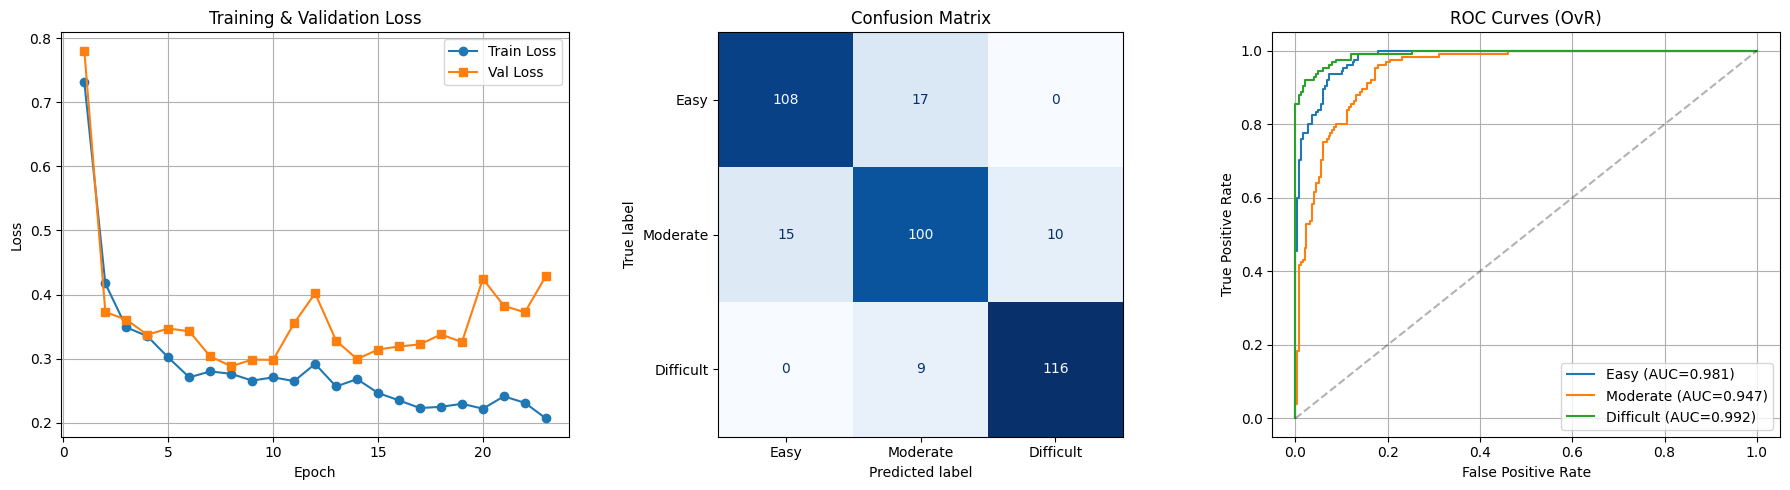

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

# Check if train_losses and val_losses exist
if 'train_losses' not in globals() or 'val_losses' not in globals():
    print("train_losses and/or val_losses are not defined. Please re-run the training cell before plotting.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss", marker="o")
    ax.plot(range(1, len(val_losses)+1), val_losses, label="Val Loss", marker="s")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training & Validation Loss")
    ax.legend()
    ax.grid(True)

    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=["Easy", "Moderate", "Difficult"],
        cmap="Blues", ax=axes[1], colorbar=False,
    )
    axes[1].set_title("Confusion Matrix")

    ax = axes[2]
    classes = ["Easy", "Moderate", "Difficult"]
    for i in range(3):
        y_bin = (y_test == i).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves (OvR)")
    ax.legend(loc="lower right")
    ax.grid(True)

    plt.tight_layout()
    plt.show()